### Figure 5a.

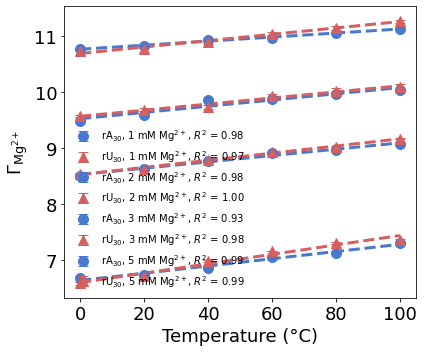

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import seaborn as sns

df = pd.read_csv("gamma_vs_temperature_all_Mg.csv")

temps = df["Temperature_C"].values
temps_fit = np.linspace(temps.min(), temps.max(), 200)

colors = sns.color_palette("muted")
color_rA = colors[0]
color_rU = colors[3]

plt.figure(figsize=(6, 5))

# Linear fit
def fit_with_scipy(x, y):
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    fit_fn = lambda xfit: slope * xfit + intercept
    return fit_fn, r_value**2, slope


Mg_list = [1, 2, 3, 5]

for Mg in Mg_list:
    # rA30
    y = df[f"rA_{Mg}mM"].values
    yerr = df[f"rA_{Mg}mM_std"].values

    fit_fn, r2, slope = fit_with_scipy(temps, y)

    plt.errorbar(
        temps, y, yerr=yerr,
        fmt="o", capsize=5,
        color=color_rA,
        markersize=10,
        alpha=1,
        label=f"rA$_{{30}}$, {Mg} mM Mg$^{{2+}}$, $R^2$ = {r2:.2f}"
    )

    plt.plot(
        temps_fit, fit_fn(temps_fit),
        "--", color=color_rA,
        linewidth=3,
        alpha=1
    )

    # rU30
    y = df[f"rU_{Mg}mM"].values
    yerr = df[f"rU_{Mg}mM_std"].values

    fit_fn, r2, slope = fit_with_scipy(temps, y)

    plt.errorbar(
        temps, y, yerr=yerr,
        fmt="^", capsize=5,
        color=color_rU,
        markersize=10,
        alpha=1,
        label=f"rU$_{{30}}$, {Mg} mM Mg$^{{2+}}$, $R^2$ = {r2:.2f}"
    )

    plt.plot(
        temps_fit, fit_fn(temps_fit),
        "--", color=color_rU,
        linewidth=3,
        alpha=1
    )


plt.xlabel("Temperature (°C)", fontsize=18)
plt.ylabel("Γ$_{\mathrm{Mg^{2+}}}$", fontsize=18)

plt.tick_params(axis="both", which="major", labelsize=18)
plt.xticks(np.arange(0, 120, 20))

plt.legend(frameon=False, fontsize=10)
plt.tight_layout()

plt.savefig("rA-rU-gamma-vs-temp-all-Mg-from-csv.svg", dpi=300)
plt.show()

### Figure 5b.

T =   0 °C | Diffusive  lambda = 5.289
T =   0 °C | Inner      lambda = 2.708
T =   0 °C | Outer      lambda = 2.803
T =  20 °C | Diffusive  lambda = 4.920
T =  20 °C | Inner      lambda = 3.091
T =  20 °C | Outer      lambda = 2.790
T =  40 °C | Diffusive  lambda = 4.602
T =  40 °C | Inner      lambda = 3.550
T =  40 °C | Outer      lambda = 2.748
T =  60 °C | Diffusive  lambda = 4.395
T =  60 °C | Inner      lambda = 3.822
T =  60 °C | Outer      lambda = 2.782
T =  80 °C | Diffusive  lambda = 4.229
T =  80 °C | Inner      lambda = 4.043
T =  80 °C | Outer      lambda = 2.827
T = 100 °C | Diffusive  lambda = 3.933
T = 100 °C | Inner      lambda = 4.281
T = 100 °C | Outer      lambda = 2.886


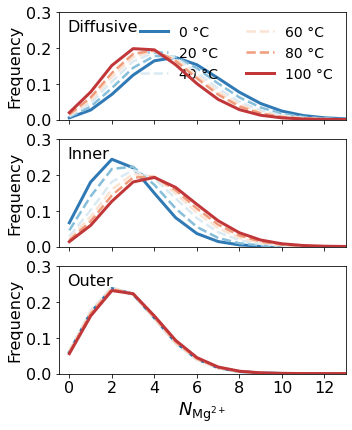

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

curr_dir = os.getcwd()
temps = np.arange(0, 120, 20)
colors = sns.color_palette("RdBu_r", n_colors=len(temps))

x = np.arange(0, 14, 1)  # discrete Poisson x values

fig, axes = plt.subplots(
    3, 1,
    figsize=(5, 6),
    sharex=True
)

panel_data = [
    ("Diffusive", 2),
    ("Inner", 0),
    ("Outer", 1),
]

for i, t in enumerate(temps):

#     folder = f"/projects/academic/nguyenh/Peter/RNA-homopolymers/pmf-temp/temp-runs/rA30/Na20/Mg5/t-{t}"
#     os.chdir(folder)

    data = np.loadtxt(f"{curr_dir}/rA30/Na20/Mg5/t-{t}/hist_data_with_diffusive.dat", comments="#")

    for ax, (label, col_idx) in zip(axes, panel_data):

        counts = data[:, col_idx]

        # Poisson fit: lambda = mean count
        lam = np.mean(counts)
        pmf = poisson.pmf(x, lam)

        linestyle = "-" if t == 0 or t == 100 else "--"

        ax.plot(
            x,
            pmf,
            linestyle=linestyle,
            color=colors[i],
            linewidth=3 if t == 0 or t == 100 else 2.5,
            label=f"{t} °C" if label == "Diffusive" else None,
            zorder=3 + i
        )

        print(f"T = {t:3d} °C | {label:10s} lambda = {lam:.3f}")

# Formatting
for ax, (label, _) in zip(axes, panel_data):
    ax.set_ylabel("Frequency", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.set_ylim(0, 0.3)

    ax.text(
        0.03, 0.82,
        label,
        transform=ax.transAxes,
        fontsize=16
    )

axes[-1].set_xlabel(r"$N_{\mathrm{Mg}^{2+}}$", fontsize=18)

axes[-1].set_xlim(-0.5, 13)
axes[-1].set_xticks(np.arange(0, 14, 2))

axes[0].legend(
    fontsize=14,
    frameon=False,
    ncol=2,
    loc="upper right"
)

plt.tight_layout()


plt.savefig(f"{curr_dir}/fig5b.svg", dpi=300)
plt.show()

### Figure 5c.

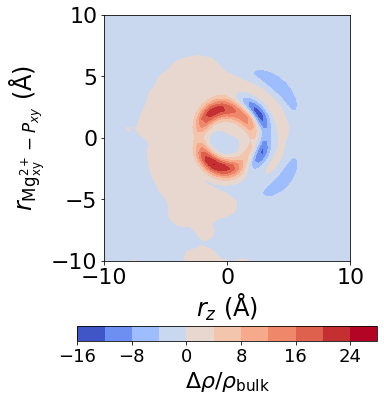

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors

curr_dir = os.getcwd()

# 0 degree C
ion_dis = np.loadtxt(f"{curr_dir}/rA30-2D-ion-projection-Na20-Mg5-t0.dat", skiprows=1)
r = ion_dis[:, 0]       # radial distance in xy-plane (e.g., r_{Mg-Pxy})
z = ion_dis[:, 1]       # axial distance (e.g., r_z)


# 2D KDE
xy = np.vstack([z, r])
kde_func = gaussian_kde(xy)
x_grid = np.linspace(z.min(), z.max(), 100)
y_grid = np.linspace(r.min(), r.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([X.ravel(), Y.ravel()])
Z = kde_func(grid_coords).reshape(X.shape)
Z *= len(r)

# Normalize KDE by bulk density
z_range = z.max() - z.min()
r_range = r.max() - r.min()
area = z_range * r_range
bulk_density = len(r) / area
Z_bulk_normalized_0C = Z / bulk_density

# 100 degree C
ion_dis = np.loadtxt(f"{curr_dir}/rA30-2D-ion-projection-Na20-Mg5-t100.dat", skiprows=1)
r = ion_dis[:, 0] 
z = ion_dis[:, 1]

# 2D KDE
xy = np.vstack([z, r])
kde_func = gaussian_kde(xy)
x_grid = np.linspace(z.min(), z.max(), 100)
y_grid = np.linspace(r.min(), r.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([X.ravel(), Y.ravel()])
Z = kde_func(grid_coords).reshape(X.shape)
Z *= len(r)

# Normalize KDE by bulk density
z_range = z.max() - z.min()
r_range = r.max() - r.min()
area = z_range * r_range
bulk_density = len(r) / area
Z_bulk_normalized_100C = Z / bulk_density  # Now in units of rho / rho_bulk

Z_bulk_normalized = Z_bulk_normalized_100C - Z_bulk_normalized_0C

norm = mcolors.TwoSlopeNorm(vmin=Z_bulk_normalized.min(),
                            vcenter=0,
                            vmax=Z_bulk_normalized.max())

fig, ax = plt.subplots(figsize=(6, 6))
cf = ax.contourf(X, Y, Z_bulk_normalized, levels=10, cmap='coolwarm', norm=norm)


cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", fraction=0.046, pad=0.2)
cbar.set_label(r"Δ$\rho / \rho_{\mathrm{bulk}}$", fontsize=22)
cbar.ax.tick_params(labelsize=18)
ax.set_aspect('equal')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel(r'$r_z$ (Å)', fontsize=24)
plt.ylabel(r'$r_{\mathrm{Mg^{2+}_{xy}} - P_{xy}}$ (Å)', fontsize=24)
plt.tick_params(axis='both', labelsize=22)
#plt.tight_layout()
plt.show()

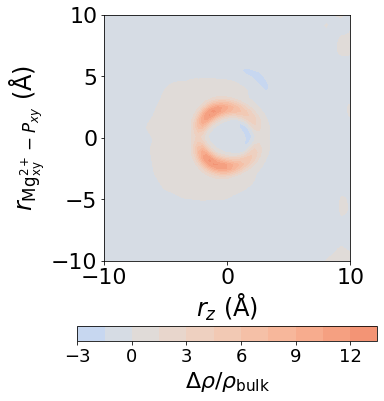

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors

curr_dir = os.getcwd()

# 0 degree C
ion_dis = np.loadtxt(f"{curr_dir}/rU30-2D-ion-projection-Na20-Mg5-t0.dat", skiprows=1)
r = ion_dis[:, 0]       # radial distance in xy-plane (e.g., r_{Mg-Pxy})
z = ion_dis[:, 1]       # axial distance (e.g., r_z)


# 2D KDE
xy = np.vstack([z, r])
kde_func = gaussian_kde(xy)
x_grid = np.linspace(z.min(), z.max(), 100)
y_grid = np.linspace(r.min(), r.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([X.ravel(), Y.ravel()])
Z = kde_func(grid_coords).reshape(X.shape)
Z *= len(r)

# Normalize KDE by bulk density
z_range = z.max() - z.min()
r_range = r.max() - r.min()
area = z_range * r_range
bulk_density = len(r) / area
Z_bulk_normalized_0C = Z / bulk_density

# 100 degree C
ion_dis = np.loadtxt(f"{curr_dir}/rU30-2D-ion-projection-Na20-Mg5-t100.dat", skiprows=1)
r = ion_dis[:, 0] 
z = ion_dis[:, 1]

# 2D KDE
xy = np.vstack([z, r])
kde_func = gaussian_kde(xy)
x_grid = np.linspace(z.min(), z.max(), 100)
y_grid = np.linspace(r.min(), r.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([X.ravel(), Y.ravel()])
Z = kde_func(grid_coords).reshape(X.shape)
Z *= len(r)

# Normalize KDE by bulk density
z_range = z.max() - z.min()
r_range = r.max() - r.min()
area = z_range * r_range
bulk_density = len(r) / area
Z_bulk_normalized_100C = Z / bulk_density  # Now in units of rho / rho_bulk

Z_bulk_normalized = Z_bulk_normalized_100C - Z_bulk_normalized_0C

# these values are from the rA30, so we can compare them fairly.
norm = mcolors.TwoSlopeNorm(vmin=-14.662707314343029,
                            vcenter=0,
                            vmax=24.12598111190557)

fig, ax = plt.subplots(figsize=(6, 6))
cf = ax.contourf(X, Y, Z_bulk_normalized, levels=10, cmap='coolwarm', norm=norm)


cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", fraction=0.046, pad=0.2)
cbar.set_label(r"Δ$\rho / \rho_{\mathrm{bulk}}$", fontsize=22)
cbar.ax.tick_params(labelsize=18)
ax.set_aspect('equal')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel(r'$r_z$ (Å)', fontsize=24)
plt.ylabel(r'$r_{\mathrm{Mg^{2+}_{xy}} - P_{xy}}$ (Å)', fontsize=24)
plt.tick_params(axis='both', labelsize=22)
#plt.tight_layout()
plt.show()